# Airbnb Athens Analysis 
Analysis of Airbnb listings in Athens, Greece, to explore pricing, review activity, and host characteristics

## 1) Setup & Imports

In [1]:
# Core
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

# Statistical modeling / diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2) Data File Setup

In [2]:
# Candidate locations for the raw dataset
candidate_paths = [
    Path("data/raw/listings.csv"),
    Path("data/listings.csv"),
    Path("listings.csv"),
]

RAW_DATA_FILE = next((p for p in candidate_paths if p.exists()), None)
RAW_DATA_FILE


PosixPath('data/raw/listings.csv')

## 3) Load Data

In [3]:
# Load the raw dataset into a DataFrame `df`.
df = None

try:
    if RAW_DATA_FILE is not None:
        df = pd.read_csv(RAW_DATA_FILE)
        print(f"Data loaded from: {RAW_DATA_FILE}")
        print("Shape:", df.shape)
    else:
        print("Dataset not found. Place listings.csv in data/raw/, data/, or the notebook folder.")
except Exception as e:
    print("Error while loading data:", e)


Data loaded from: data/raw/listings.csv
Shape: (15632, 18)


## 4) Quick Data Overview

In [4]:
if df is not None:
    
    #peek at the data set
    print("\nInfo:")
    display(df.head())

    #Missing values
    print("\nMissing values (top 10):")
    display(df.isna().sum().sort_values(ascending=False).head(10))

    # Count total duplicate rows
    num_duplicates = df.duplicated().sum()
    print(f"Total duplicate rows: {num_duplicates}")

    # Count duplicates in 'id'
    num_id_duplicates = df.duplicated(subset=['id']).sum()
    print(f"Duplicate listings by ID: {num_id_duplicates}")
    
else:
    print("ℹ️ Load your data first in the previous cell.")


Info:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,NaN,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire home/apt,NaN,1,29,2024-11-18,0.19,1,0,4,00002433111
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,23.72775,Entire home/apt,35.0,4,83,2025-06-18,0.47,2,315,13,00000874421
2,7457792,Athens Kolonaki Stay!,6761879,Patrick,NaN,ΚΟΛΩΝΑΚΙ,37.97825,23.75044,Entire home/apt,52.0,3,34,2025-05-12,0.29,1,266,5,00000112611
3,7506567,Plaka Penthouse with view to Acropolis,15423131,Cristi,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97483,23.73201,Entire home/apt,129.0,3,97,2025-06-07,0.99,1,364,7,00000236660
4,7559058,Awarded Loft in the Center of Athens,14184069,Manos,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.98390,23.71874,Entire home/apt,NaN,1,578,2025-06-10,4.80,8,293,45,00003163949



Missing values (top 10):


neighbourhood_group    15632
reviews_per_month       2509
last_review             2509
price                    781
host_name                520
license                  203
name                       0
id                         0
neighbourhood              0
host_id                    0
dtype: int64

Total duplicate rows: 0
Duplicate listings by ID: 0


## 5) Data Dictionary

| Column                         | Description                                                   | Example                |
|--------------------------------|---------------------------------------------------------------|------------------------|
| `id`                           | Unique identifier for the Airbnb listing                      | 12345678               |
| `name`                         | Title or name of the listing                                  | "Cozy Studio near Metro" |
| `host_id`                      | Unique identifier for the host                                | 987654                 |
| `host_name`                    | Host’s display name                                           | "Maria"                |
| `neighbourhood_group`          | Empty in this dataset (all nulls). Can be dropped             | —                      |
| `neighbourhood`                | Area in Athens of the listing                                 | "Koukaki"              |
| `latitude`, `longitude`        | Geographic coordinates of the property                        | 37.9715, 23.7257       |
| `room_type`                    | Type of accommodation (Entire home/apt, Private room, Shared room) | "Entire home/apt" |
| `price`                        | Nightly price in euros                                        | 85                     |
| `minimum_nights`               | Minimum number of nights required per booking                 | 2                      |
| `number_of_reviews`            | Total reviews received                                        | 45                     |
| `last_review`                  | Date of the most recent review                                | 2024-06-15             |
| `reviews_per_month`            | Average number of reviews per month (nullable)                | 1.2                    |
| `calculated_host_listings_count`| Number of total listings owned by the host                   | 3                      |
| `availability_365`             | Days available for booking in a year                          | 180                    |
| `number_of_reviews_ltm`        | Reviews received in the last 12 months                        | 12                     |
| `license`                      | Official short-term rental license number (may be missing/inconsistent) | "000012345" |


## 6) Data Cleaning Plan

Steps taken to prepare the dataset:

1. **Removed irrelevant columns**
   - Dropped `neighbourhood_group` (all values were null).

2. **Price filtering**
   - Dropped rows without a price.  
   - Kept only listings with `0 < price ≤ 1500` EUR (to remove free/mistaken entries and extreme outliers).  

3. **Minimum nights**
   - Dropped extreme values where `minimum_nights > 365`.  
   - Retained rare but valid long-term stays (30–365 nights) for context.

4. **Missing values**
   - Filled missing `reviews_per_month` with `0`.  
   - Replaced missing `last_review` with `"No Review"`.  
   - Replaced missing `license` with `"Unlicensed"`.  

5. **Duplicates**
   - Removed duplicate rows to avoid over-counting listings.  

6. **Feature consistency**
   - Converted `price` column to numeric (removed symbols, parsed strings).  
   - Created log-transformed versions of skewed features (e.g., `log_price`, `log_minimum_nights`, `log_reviews`).  

---


### Assumptions & Limitations

- **Prices**  
  - Assumed listings priced at `0` are errors so they were removed.  
  - Listings above `1500 €/night` were excluded as extreme outliers unlikely to represent typical market behavior.  

- **Minimum nights**  
  - Allowed values between `1` and `365`.  
  - Extreme stays (30–365 nights) were retained but treated as rare cases.  

- **Licenses**  
  - Missing licenses were labeled `"Unlicensed"`.  
  - No attempt was made to validate license formats (possible inconsistencies remain).  

- **Reviews**  
  - Missing `reviews_per_month` were treated as `0`.  
  - Missing `last_review` were set to `"No Review"`.  

- **Duplicates**  
  - Removed exact duplicate rows and duplicate IDs to avoid inflating the dataset.  

- **General note**  
  - Dataset represents Airbnb listings at one point in time and may not reflect future changes (e.g., regulatory updates in Athens).


## 7) Data Cleaning Steps

In [6]:
df_clean = None

if df is not None:
    df_clean = df.copy()

    # Drop irrelevant columns
    df_clean = df_clean.drop(columns=['neighbourhood_group'], errors="ignore")
    # 2. Handle price
    # Ensure numeric (remove symbols, drop blanks)
    df_clean["price"] = (
        df_clean["price"]
        .astype(str)
        .str.replace(r"[^0-9.]", "", regex=True)
)

    # Drop rows where price turned into empty string
    df_clean = df_clean[df_clean["price"].str.strip() != ""]

    # Convert to float
    df_clean["price"] = df_clean["price"].astype(float)

    # Keep only reasonable range: (0, 1500]
    df_clean = df_clean.dropna(subset=['price'])
    df_clean = df_clean[(df_clean['price'] > 0) & (df_clean['price'] <= 1500)]

    # Handle missing values
    df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
    df_clean['last_review'] = df_clean['last_review'].fillna("No Review")
    df_clean['license'] = df_clean['license'].fillna("Unlicensed")

    # Handle minimum_nights
    df_clean = df_clean[df_clean['minimum_nights'] <= 365]

    # Drop duplicates
    df_clean = df_clean.drop_duplicates(subset=["id"], keep="first")

    # Reset index
    df_clean = df_clean.reset_index(drop=True)

    # Removed Hotels on Airbnb (48 listings) as they distort the distribution
    df_clean = df_clean[df_clean['room_type'] != 'Hotel room']
    
    # Used log scale of price as price doesn't have a normal distribution
    df_clean['log_price'] = df_clean['price'].apply(lambda x: np.log(x) if x > 0 else 0)

    # neighborhood names transliteration
    greek_to_english = {
    'ΚΟΥΚΑΚΙ - ΜΑΚΡΥΓΙΑΝΝΗ': 'Koukaki-Makrygianni','ΠΑΓΚΡΑΤΙ': 'Pagkrati','ΑΜΠΕΛΟΚΗΠΟΙ': 'Ampelokipoi','ΚΕΝΤΡΟ': 'Center',
    'ΜΕΤΑΞΟΥΡΓΕΙΟ': 'Metaxourgeio','ΠΕΤΡΑΛΩΝΑ': 'Petralona','ΝΕΟΣ ΚΟΣΜΟΣ': 'Neos Kosmos','ΕΞΑΡΧΕΙΑ': 'Exarchia',
    'ΚΥΨΕΛΗ': 'Kypseli','ΓΚΑΖΙ': 'Gazi','ΚΟΛΩΝΑΚΙ': 'Kolonaki','ΝΕΑ ΣΜΥΡΝΗ': 'Nea Smyrni','ΘΗΣΕΙΟ': 'Thisseio',
    'ΑΚΡΟΠΟΛΗ': 'Acropolis','ΙΛΙΣΙΑ': 'Ilisia','ΣΤΑΔΙΟ': 'Stadio','ΚΕΡΑΜΕΙΚΟΣ':'Kerameikos','ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ':'Plateia Attikis',
    'ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ':'Agios Konstantinos - Plateia Vathis','ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ':'Mouseio-Exarcheia-Neapoli',
    'ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ':'Koukaki-Makrugianni','ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ':'Eboriko Trigono-Plaka','ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ':'Agios Nikolaos',
    'ΝΕΑ ΚΥΨΕΛΗ':'Nea Kypseli','ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ':'Plateia Amerikis','ΓΟΥΔΙ':'Goudi','ΛΥΚΑΒΗΤΤΟΣ':'Lykavittos','ΠΑΤΗΣΙΑ': 'Patisia',
    'ΠΕΔΙΟ ΑΡΕΩΣ':'Pedio Areos','ΕΛΛΗΝΟΡΩΣΩΝ':'Ellinoroson','ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ':'Stathmos Larisis','ΑΝΩ ΠΑΤΗΣΙΑ':'Ano Patisia',
    'ΑΚΑΔΗΜΙΑ ΠΛΑΤΩΝΟΣ':'Akadimia Platonos','ΓΚΥΖΗ':'Gyzi','ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ':'Agios Eleftherios','ΓΟΥΒΑ':'Gouva',
    'ΣΕΠΟΛΙΑ':'Sepolia','ΑΝΩ ΚΥΨΕΛΗ':'Ano Kypseli','ΚΟΛΩΝΟΣ':'Kolonos','ΠΡΟΜΠΟΝΑ':'Probona','ΝΙΡΒΑΝΑ':'Nirvana',
    'ΖΑΠΠΕΙΟ':'Zappeio','1Ο ΝΕΚΡΟΤΑΦΕΙΟ':'10o Nekrotafio','ΒΟΤΑΝΙΚΟΣ':'Votanikos','ΚΟΛΟΚΥΝΘΟΥ':'Kolokynthou','ΡΗΓΙΛΛΗΣ':'Rigillis',
    'ΡΙΖΟΥΠΟΛΗ':'Rizoupoli','ΠΟΛΥΓΩΝΟ':'Polygono','ΠΕΝΤΑΓΩΝΟ':'Pentagono'
    }

    # Apply transliteration
    df_clean['neighbourhood'] = df_clean['neighbourhood'].replace(greek_to_english)

    # Summary
    print(f"Cleaning complete. Final shape: {df_clean.shape}")
    print(f"{len(df) - len(df_clean)} listings removed during cleaning.")
else:
    print("Load your data first in section 3.")


Cleaning complete. Final shape: (14756, 18)
876 listings removed during cleaning.


## 8) Exploratory Data Analysis (EDA)

We explore the dataset with the goal of understanding key patterns in:

1. **Price distribution**
2. **Room types**
3. **Geographic location**
4. **Reviews**
5. **Host behavior**
6. **Licensing**
7. **Listing Name Analysis**

## 8.1 Price Distribution

Prices are highly skewed: most listings are concentrated under €200 per night, with a long tail extending to €1500.  
A log transformation produces a more symmetric distribution, making comparisons easier.

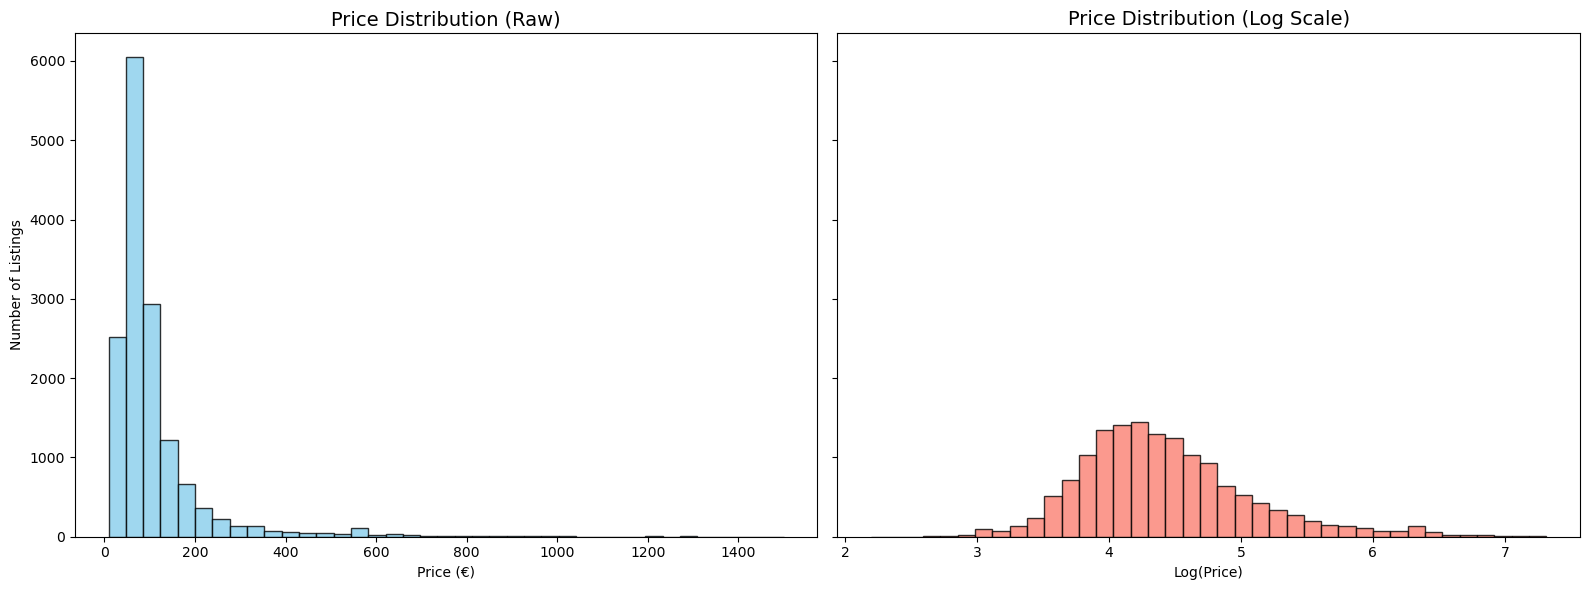

In [7]:
TARGET = "price"  

if df_clean is not None and TARGET in df_clean.columns: 
    # Set up figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Define bins for consistency
    raw_bins = np.linspace(df_clean['price'].min(), df_clean['price'].max(), 40)
    log_bins = np.linspace(df_clean['log_price'].min(), df_clean['log_price'].max(), 40)

    # Raw price histogram
    axes[0].hist(df_clean['price'], bins=raw_bins, color='skyblue', edgecolor='black', alpha=0.8)
    axes[0].set_title("Price Distribution (Raw)", fontsize=14)
    axes[0].set_xlabel("Price (€)")
    axes[0].set_ylabel("Number of Listings")

    # Log price histogram
    axes[1].hist(df_clean['log_price'], bins=log_bins, color='salmon', edgecolor='black', alpha=0.8)
    axes[1].set_title("Price Distribution (Log Scale)", fontsize=14)
    axes[1].set_xlabel("Log(Price)")

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Ensure df_clean exists and TARGET is set correctly.")

### Price Bands

For interpretability, listings were grouped into five price bands (Budget, Affordable,Mid-Range,Luxury and High-end) based on nightly price ranges.

In [8]:
bins = [0, 50, 100, 200, 600, 1500]
labels = ['Budget', 'Affordable', 'Mid-range', 'Luxury', 'High-end']
df_clean['price_band'] = pd.cut(df_clean['price'], bins=bins, labels=labels, include_lowest=True)

### Price Clusters (K-means)

To complement the rule-based bands, we applied KMeans clustering on `log_price`.  
The resulting clusters align closely with the manual bands.  
The KDE plot shows how the clusters overlap and differ in scale, while the table provides an interpretation in euros.


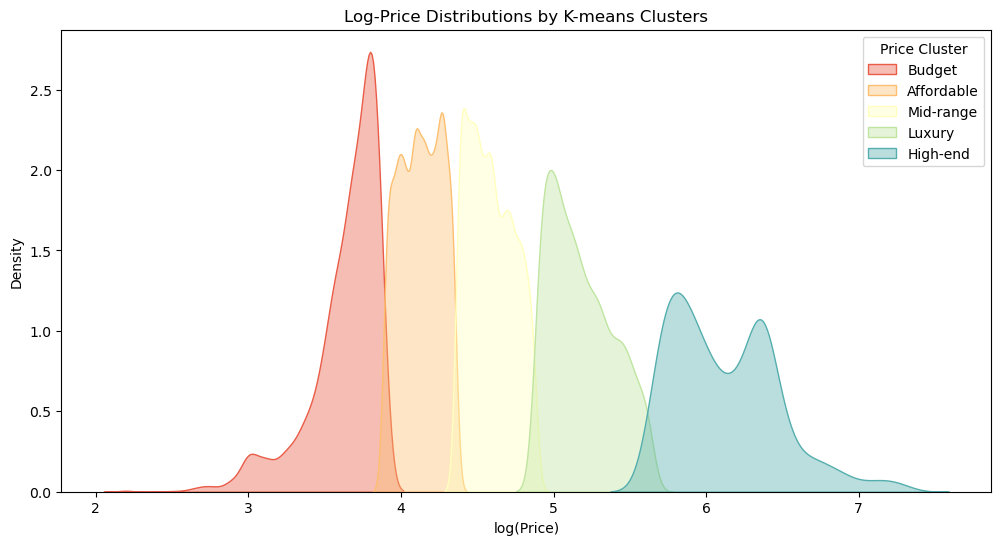

,min,median,max
price_kmeans_named,,,
Budget,9.0,40.0,48.0
Affordable,49.0,62.0,78.0
Mid-range,79.0,97.0,132.0
Luxury,133.0,171.0,284.0
High-end,285.0,435.0,1500.0


In [9]:
# K-means clustering on log_price
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df_clean['price_kmeans'] = kmeans.fit_predict(df_clean[['log_price']])

# Map clusters to interpretable labels by median price
cluster_order = df_clean.groupby('price_kmeans')['price'].median().sort_values().index
manual_labels = ['Budget', 'Affordable', 'Mid-range', 'Luxury', 'High-end']
cluster_label_map = {old: new for old, new in zip(cluster_order, manual_labels)}
df_clean['price_kmeans_named'] = df_clean['price_kmeans'].map(cluster_label_map)

# KDE plots
palette = sns.color_palette("Spectral", n_colors=len(manual_labels))
plt.figure(figsize=(12,6))

for cluster, color in zip(manual_labels, palette):
    subset = df_clean[df_clean['price_kmeans_named'] == cluster]['log_price']
    sns.kdeplot(subset, label=cluster, color=color, fill=True, alpha=0.4)

plt.title("Log-Price Distributions by K-means Clusters")
plt.xlabel("log(Price)")
plt.ylabel("Density")
plt.legend(title="Price Cluster")
plt.show()

# Cluster interpretation table
df_clean.groupby('price_kmeans_named')['price'].agg(['min','median','max']).sort_values('median')

### Price Distribution & Clusters

- **Skewed distribution**: Raw prices are highly right-skewed, with a few extreme values distorting the mean. A log transformation normalizes the distribution and makes analysis feasible.  
- **Price bands**: Grouping listings into 5 price bands (Budget → High-end) improves interpretability. The majority of listings fall into the Budget and Affordable categories.  
- **K-means validation**: K-means clustering on log-price yields a similar segmentation to manual price bands, confirming the existence of distinct market tiers.  
- **Interpretation**:  
  - **Budget (<€50)**: Highly competitive, many listings.  
  - **Affordable (€50–100)**: Largest segment, especially near metro-accessible areas.  
  - **Mid-range (€100–200)**: More comfort, central locations.  
  - **Luxury (€200–600)**: Premium locations and amenities.  
  - **High-end (>€600)**: Rare listings, exclusive properties.  

**Takeaway**: Price segmentation is meaningful and will help link supply/demand patterns to traveler preferences.


## 8.2 Room Type Analysis

Airbnb listings in Athens are mostly Entire homes/apartments, followed by Private rooms.  
Room type is strongly associated with price levels and host behavior (availability, number of listings).


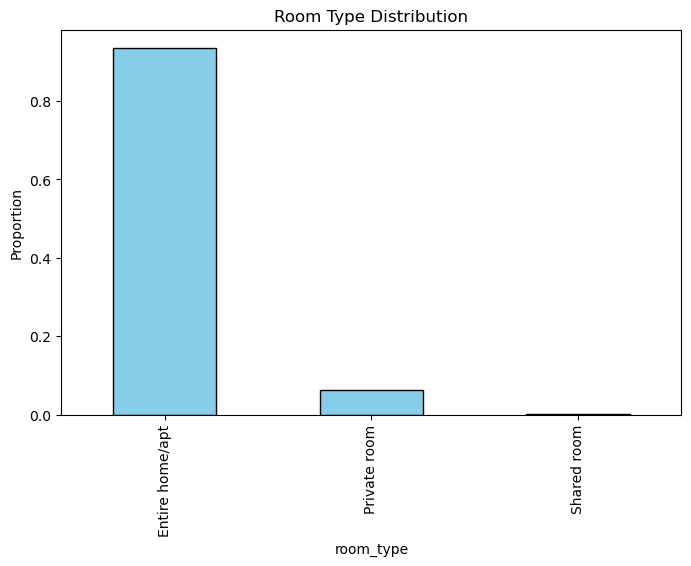

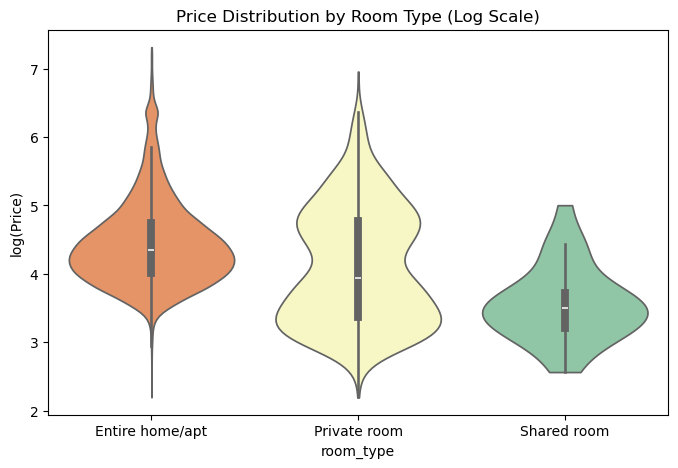

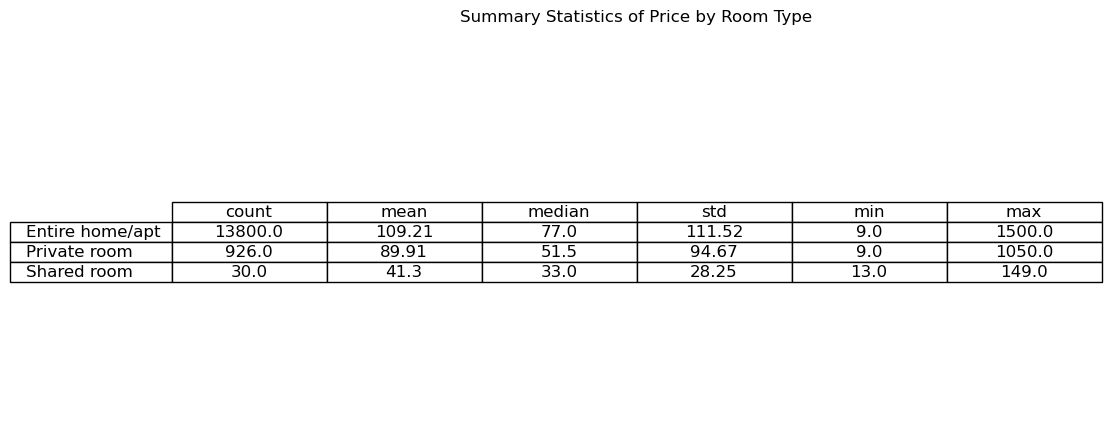

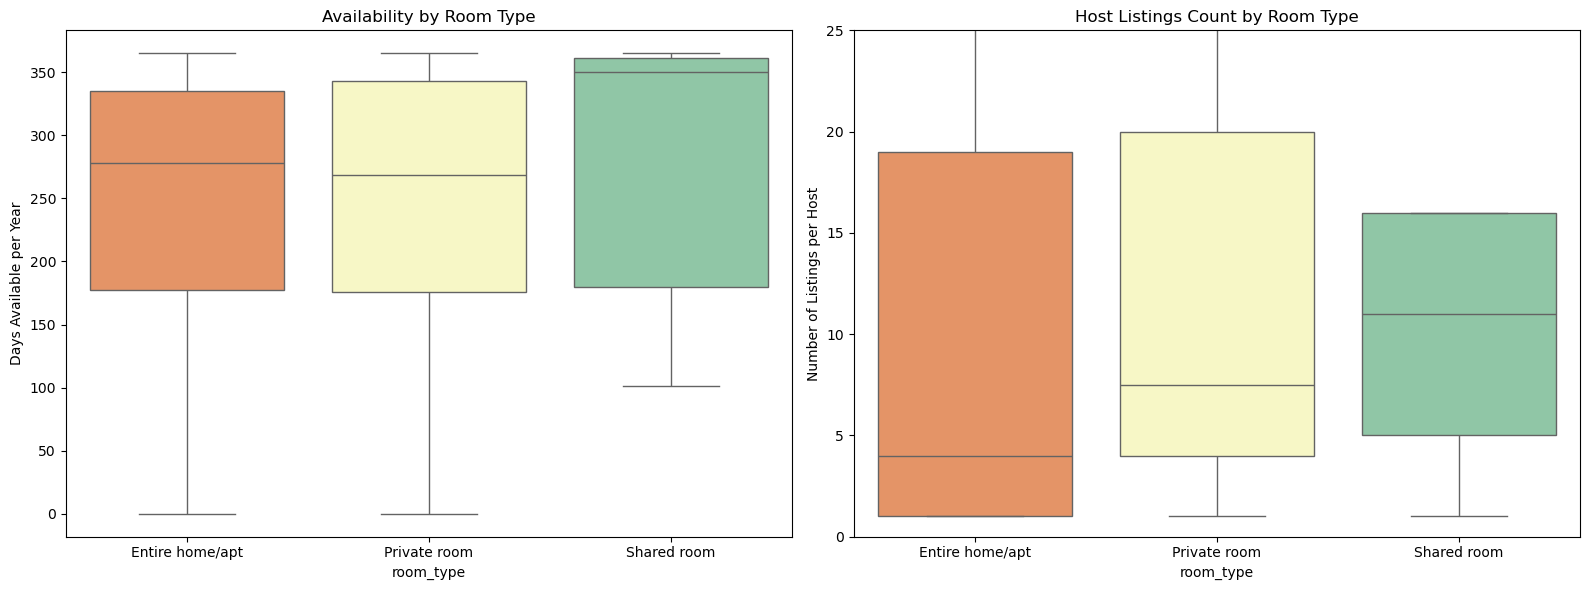

In [10]:
# Distribution of listings
df_clean['room_type'].value_counts(normalize=True).plot(kind='bar', figsize=(8,5), color="skyblue", edgecolor="black")
plt.title("Room Type Distribution")
plt.ylabel("Proportion")
plt.show()

# Price distribution by room type (violin, log scale)
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df_clean, x='room_type', y='log_price',
    hue='room_type', palette='Spectral', legend=False, cut=0
)
plt.title("Price Distribution by Room Type (Log Scale)")
plt.ylabel("log(Price)")
plt.show()

# Summary statistics
summary_stats = df_clean.groupby('room_type')['price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
tbl = ax.table(
    cellText=summary_stats.values,
    colLabels=summary_stats.columns,
    rowLabels=summary_stats.index,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 1.2)
plt.title("Summary Statistics of Price by Room Type", pad=20)
plt.show()

# Operational characteristics
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.boxplot(
    data=df_clean, x='room_type', y='availability_365',
    hue='room_type', palette='Spectral', legend=False, ax=axes[0]
)
axes[0].set_title("Availability by Room Type")
axes[0].set_ylabel("Days Available per Year")

sns.boxplot(
    data=df_clean, x='room_type', y='calculated_host_listings_count',
    hue='room_type', palette='Spectral', legend=False, ax=axes[1]
)
axes[1].set_ylim(0, 25)  # Limit for readability
axes[1].set_title("Host Listings Count by Room Type")
axes[1].set_ylabel("Number of Listings per Host")

plt.tight_layout()
plt.show()


### Room Type Insights

- **Distribution**: Entire home/apartment dominates the market. Shared rooms and private rooms represent only a small fraction of listings.  
- **Pricing**: Entire homes/apartments command significantly higher prices, while private rooms and shared rooms are markedly cheaper.  
- **Availability & hosts**: Shared rooms show the highest yearly availability and are often managed by hosts with many listings. Entire homes and private rooms show lower availability and are more commonly managed by individual or small-scale hosts.  

**Takeaway**: Room type strongly shapes both pricing and host behavior. Entire apartments dominate Athens’ Airbnb market, while shared and private rooms are more often associated with multi-listing hosts.


## 8.3 Neighborhood & Location Analysis

Airbnb listings in Athens are concentrated in a handful of central neighborhoods. Prices vary substantially across these areas, with distinct geographic clustering patterns.


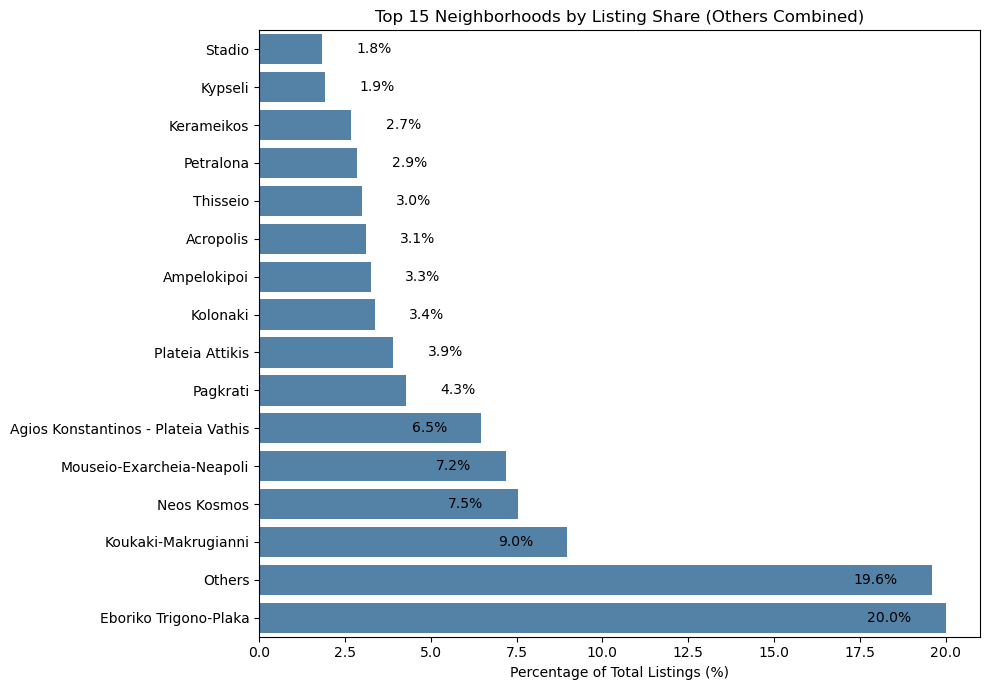

In [11]:
# Neighborhood Concentration
# Count listings per neighborhood
neighborhood_counts = df_clean['neighbourhood'].value_counts()

# Split into top 15 and combine the rest under"Others"
top15 = neighborhood_counts[:15]
others = neighborhood_counts[15:].sum()
data = pd.concat([top15, pd.Series({'Others': others})])

# Convert to percentage
total = data.sum()
neigh_summary = (data / total * 100).round(2).sort_values(ascending=True).reset_index()
neigh_summary.columns = ['Neighborhood', 'Percentage']

# Plot
plt.figure(figsize=(10,7))
sns.barplot(
    data=neigh_summary,
    x='Percentage',
    y='Neighborhood',
    color='steelblue'  
)

# Add percentage labels dynamically
for i, val in enumerate(neigh_summary['Percentage']):
    xpos = val - 1 if val > 5 else val + 1  # inside bar if large enough
    align = 'right' if val > 5 else 'left'
    plt.text(xpos, i, f"{val:.1f}%", va='center', ha=align, color='black')

plt.title("Top 15 Neighborhoods by Listing Share (Others Combined)")
plt.xlabel("Percentage of Total Listings (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

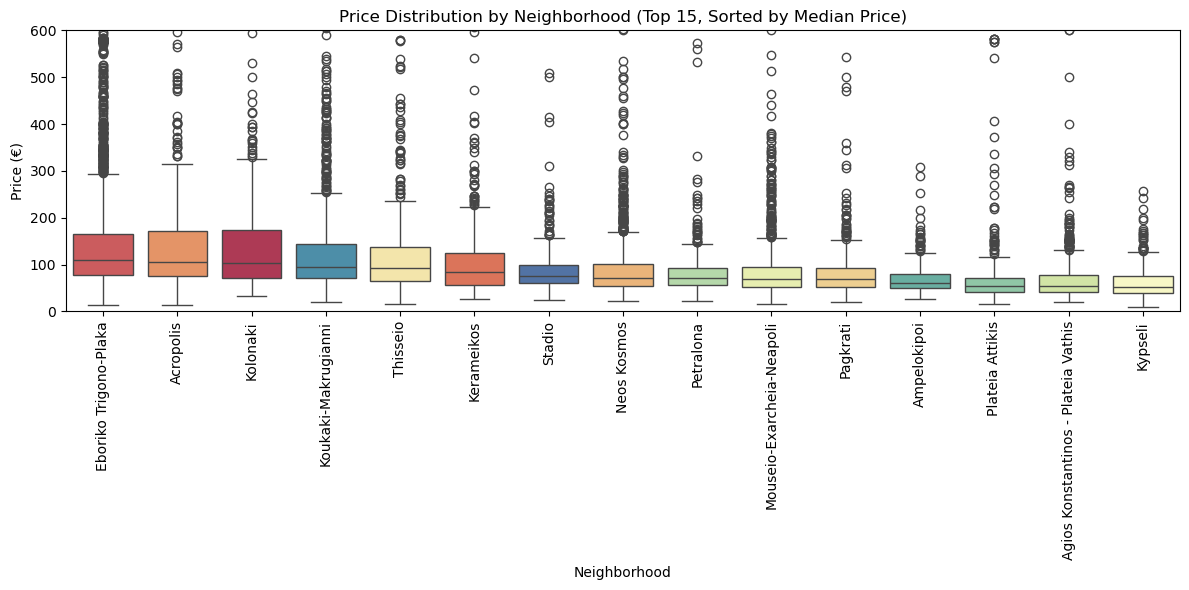

In [12]:
# Price distribution by neighborhood
# Filter top 15
top15_neigh = df_clean['neighbourhood'].value_counts().head(15).index
df_top15 = df_clean[df_clean['neighbourhood'].isin(top15_neigh)]

# Sort by median price
median_prices = df_top15.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top15,
    x='neighbourhood',
    y='price',
    hue='neighbourhood',
    legend=False,
    order=median_prices,
    palette="Spectral"
)
plt.ylim(0, 600)
plt.xticks(rotation=90)
plt.title("Price Distribution by Neighborhood (Top 15, Sorted by Median Price)")
plt.xlabel("Neighborhood")
plt.ylabel("Price (€)")
plt.tight_layout()
plt.show()

Finally, the plot below shows how the price clusters are distributed across Athens, linking affordability patterns to location.

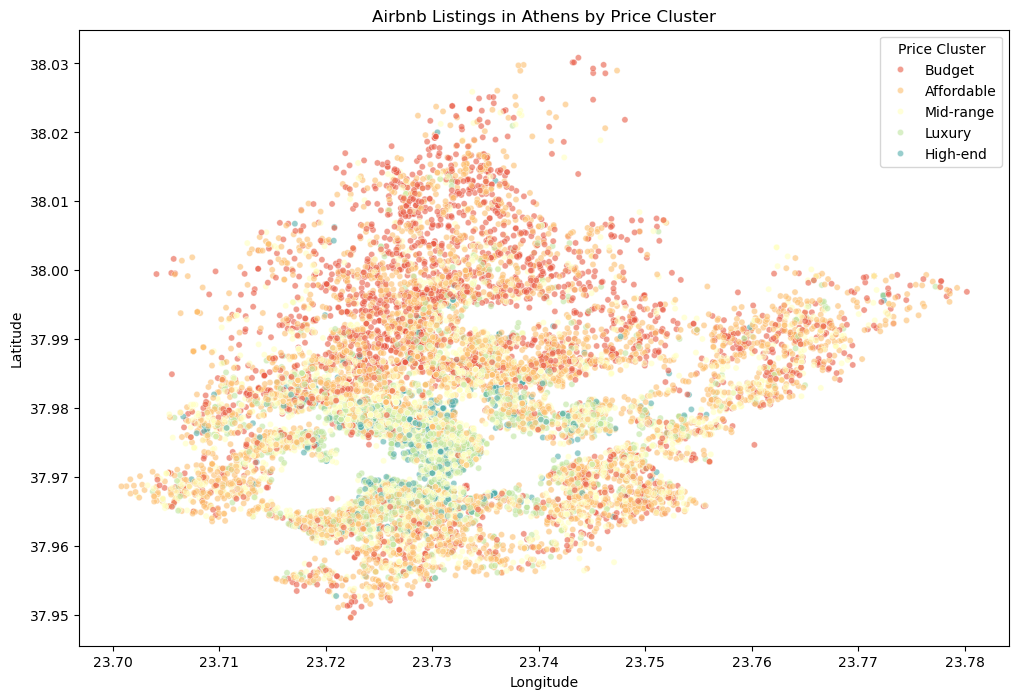

In [13]:
# Geographic context
# Scatterplot by location and price cluster
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue='price_kmeans_named',
    palette="Spectral",
    alpha=0.6,
    s=20
)
plt.title("Airbnb Listings in Athens by Price Cluster")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Price Cluster")
plt.show()

### Neighborhood Insights

Airbnb listings in Athens are heavily concentrated in the central zone, with over 40% of all properties located within walking distance of the Acropolis and Plaka. This tourist core — including Eboriko Trigono-Plaka, Koukaki-Makrygianni, Thisseio, Petralona, and Kolonaki — commands the city’s highest prices and reflects the dominance of short-term accommodation around key landmarks.

A second tier of neighborhoods such as Pagkrati, Stadio, Neos Kosmos, Exarchia, and Kerameikos forms an expanded inner ring. These districts blend residential and visitor activity, offering more varied prices and a growing share of mid- to high-end listings.

Beyond the center, roughly 20% of listings lie across outer districts like Ampelokipoi, Kypseli, Vathi, and Plateia Attikis. These areas remain more residential and tend to host a larger share of budget-oriented listings.

**Takeaway**: The Athens Airbnb market follows a clear spatial hierarchy, from premium tourist areas around the Acropolis to secondary zones with lower prices and more dispersed supply. Location remains the strongest single determinant of both price and listing density.


##  8.4 Host Analysis

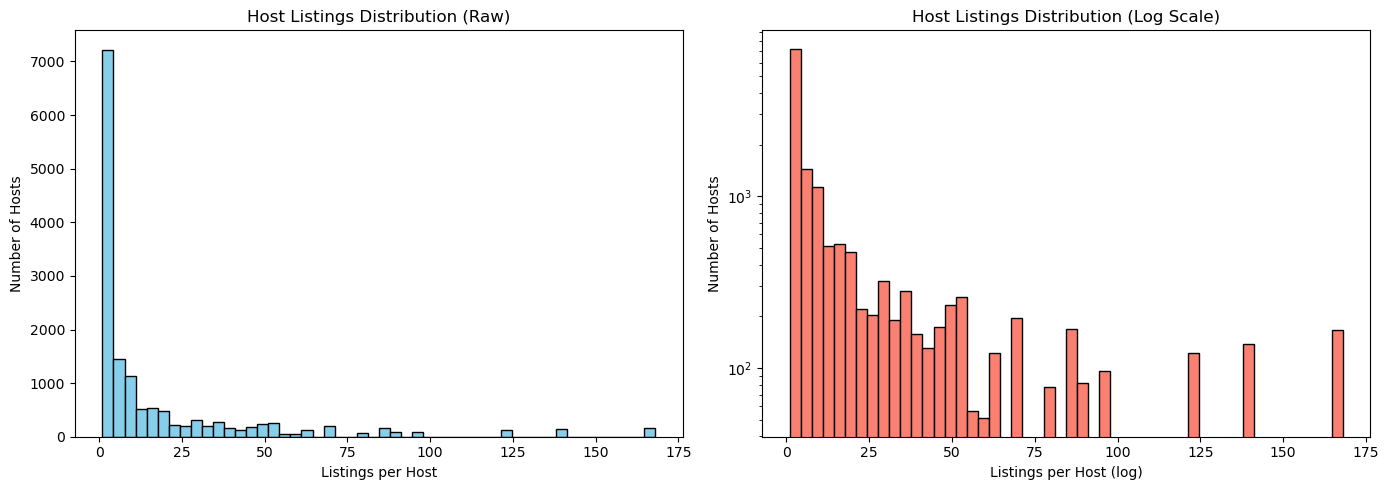

In [14]:
#  Distribution of host listings (per host)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
axes[0].hist(df_clean['calculated_host_listings_count'], bins=50, color="skyblue", edgecolor="black")
axes[0].set_title("Host Listings Distribution (Raw)")
axes[0].set_xlabel("Listings per Host")
axes[0].set_ylabel("Number of Hosts")

# Log scale
axes[1].hist(df_clean['calculated_host_listings_count'], bins=50, color="salmon", edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_title("Host Listings Distribution (Log Scale)")
axes[1].set_xlabel("Listings per Host (log)")
axes[1].set_ylabel("Number of Hosts")

plt.tight_layout()
plt.show()

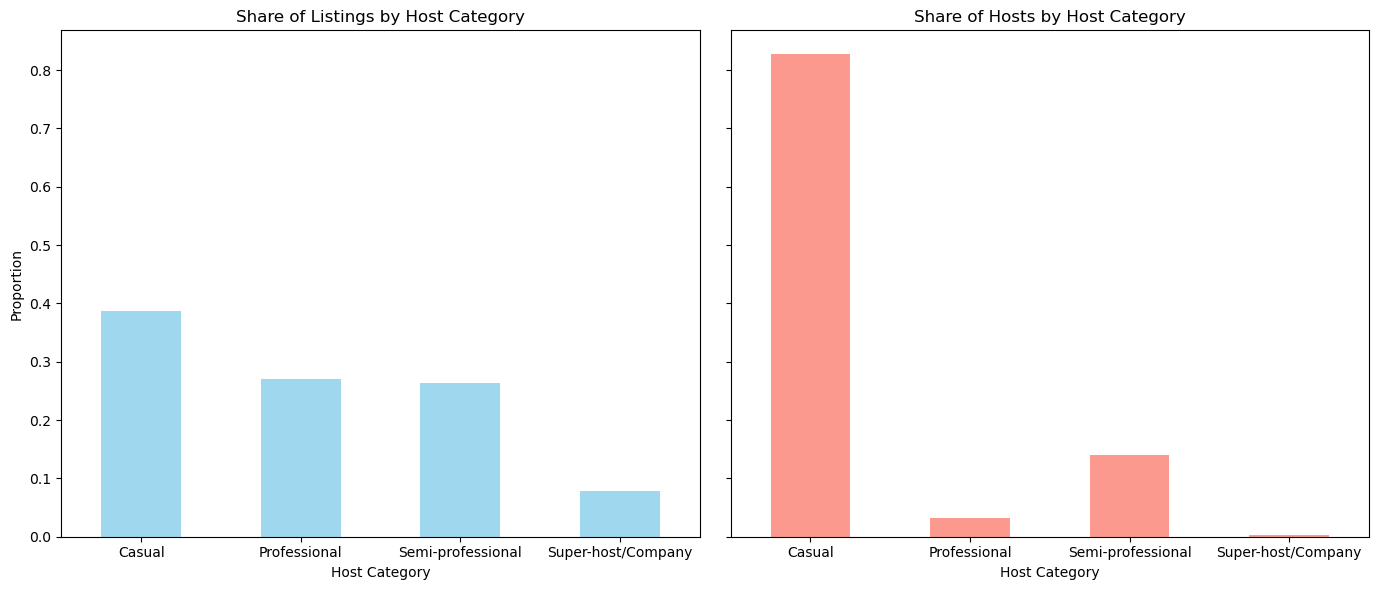

In [15]:
# Categorize hosts 
def categorize_host(listings):
    if listings <= 2:
        return "Casual"
    elif listings <= 10:
        return "Semi-professional"
    elif listings <= 60:
        return "Professional"
    else:
        return "Super-host/Company"

df_clean['host_category'] = df_clean['calculated_host_listings_count'].apply(categorize_host)

# Shares of listings vs hosts
listing_shares = df_clean['host_category'].value_counts(normalize=True).sort_index()
host_counts = (
    df_clean[['host_id','host_category']]
    .drop_duplicates()['host_category']
    .value_counts(normalize=True)
    .sort_index()
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

listing_shares.plot(kind='bar', color="skyblue", alpha=0.8, ax=axes[0])
axes[0].set_title("Share of Listings by Host Category")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Host Category")
axes[0].tick_params(axis='x', rotation=0)

host_counts.plot(kind='bar', color="salmon", alpha=0.8, ax=axes[1])
axes[1].set_title("Share of Hosts by Host Category")
axes[1].set_xlabel("Host Category")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5373/4096568627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='host_category', y='price', palette="Spectral")


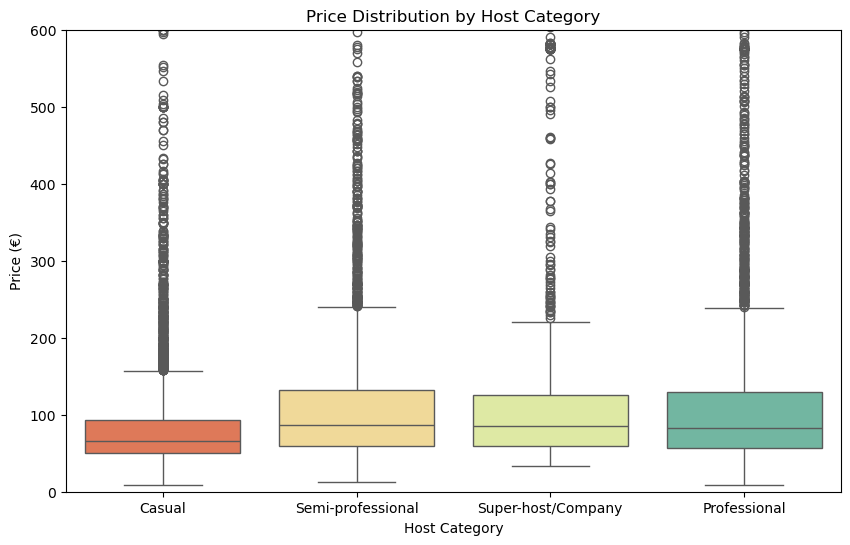

In [16]:
# Price differences by host category
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='host_category', y='price', palette="Spectral")
plt.ylim(0, 600)  # cutoff for readability
plt.title("Price Distribution by Host Category")
plt.xlabel("Host Category")
plt.ylabel("Price (€)")
plt.show()

/tmp/ipykernel_5373/798144787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_reviews, x='host_category', y='number_of_reviews', palette="Spectral")


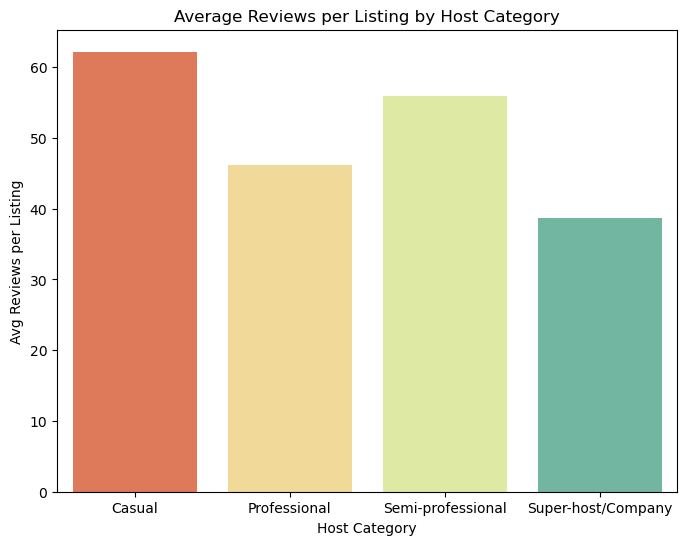

In [17]:
# Average reviews per listing by host category
avg_reviews = df_clean.groupby('host_category')['number_of_reviews'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_reviews, x='host_category', y='number_of_reviews', palette="Spectral")
plt.title("Average Reviews per Listing by Host Category")
plt.xlabel("Host Category")
plt.ylabel("Avg Reviews per Listing")
plt.show()

/tmp/ipykernel_5373/4136514806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_availability, x='host_category', y='availability_365', palette="Spectral")


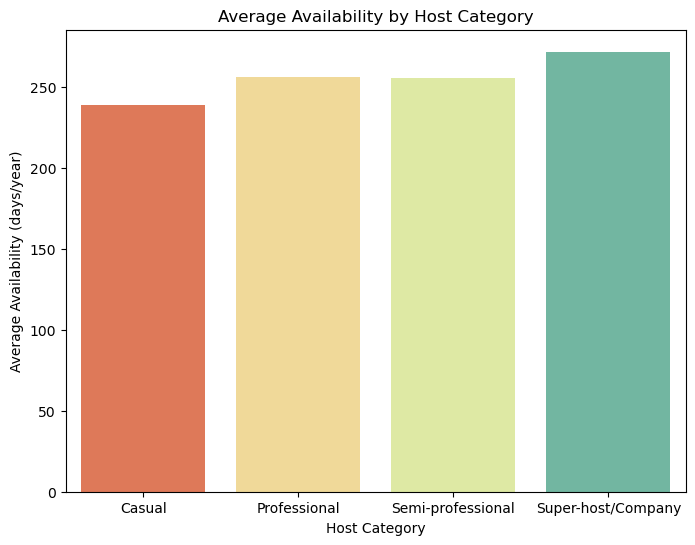

In [18]:
# Availability by host category
avg_availability = df_clean.groupby('host_category')['availability_365'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_availability, x='host_category', y='availability_365', palette="Spectral")
plt.title("Average Availability by Host Category")
plt.xlabel("Host Category")
plt.ylabel("Average Availability (days/year)")
plt.show()

### Host Insights

- The majority of hosts are casual (two listings or fewer), but a large share of total supply is controlled by professional hosts and companies.  
- Professional hosts charge slightly higher prices on average, while casual hosts are more concentrated in the budget and mid-range segments.  
- Casual hosts receive more reviews per listing, while companies and super-hosts tend to keep listings open for longer periods.

**Takeaway**: Host type shapes supply patterns in Athens. Casual hosts dominate by count, but professional operators play a disproportionate role in availability and overall market presence.


## 8.5 Reviews Analysis

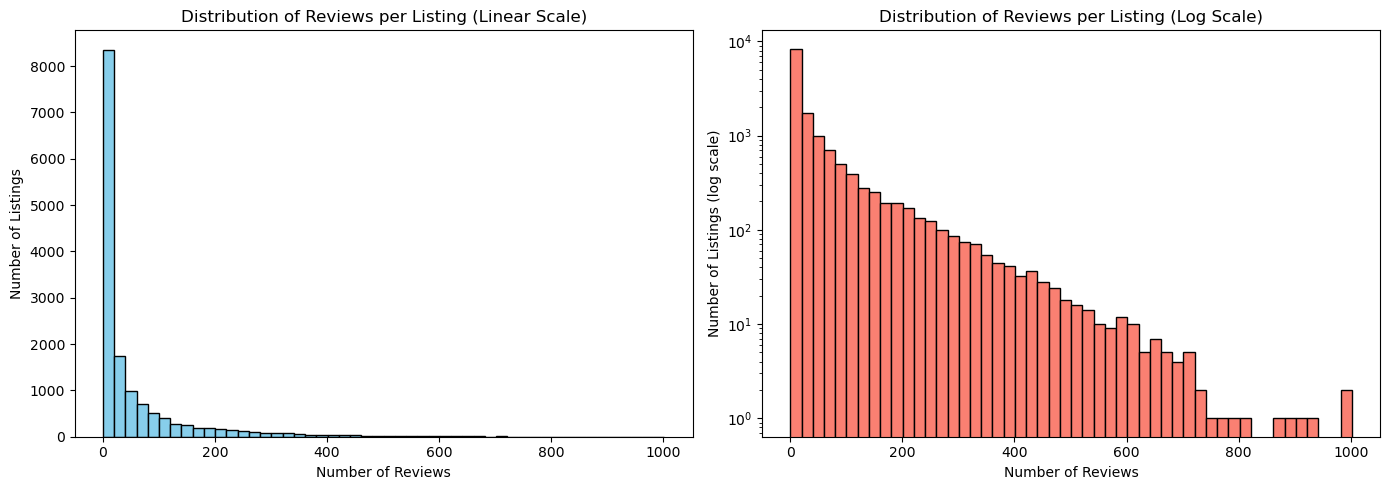

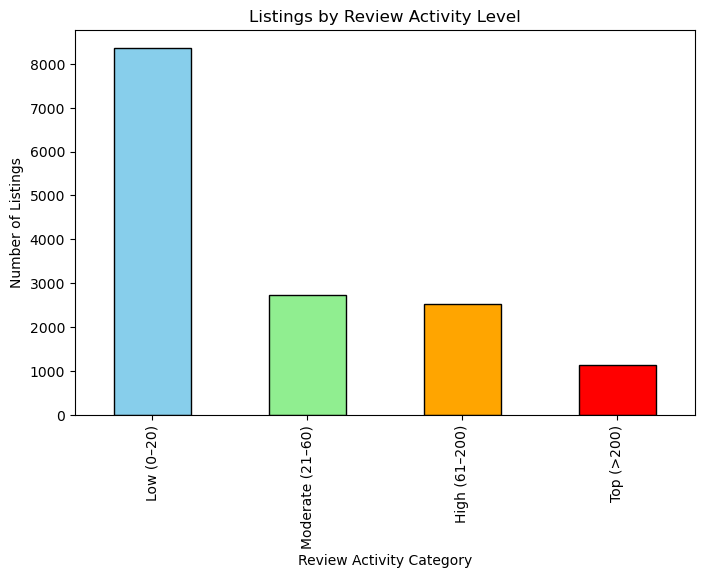

In [19]:
# Columns: number_of_reviews, reviews_per_month, last_review, number_of_reviews_ltm
# ---------------------------------------------

# Distribution of reviews per listing
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Linear scale
axes[0].hist(df_clean['number_of_reviews'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title("Distribution of Reviews per Listing (Linear Scale)")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Number of Listings")

# Log scale
axes[1].hist(df_clean['number_of_reviews'], bins=50, color='salmon', edgecolor='black', log=True)
axes[1].set_title("Distribution of Reviews per Listing (Log Scale)")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Number of Listings (log scale)")

plt.tight_layout()
plt.show()

# Categorize review activity
bins = [0, 20, 60, 200, df_clean['number_of_reviews'].max()]
labels = ['Low (0–20)', 'Moderate (21–60)', 'High (61–200)', 'Top (>200)']

df_clean['review_activity'] = pd.cut(
    df_clean['number_of_reviews'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(8,5))
df_clean['review_activity'].value_counts().reindex(labels).plot(
    kind='bar',
    color=['skyblue','lightgreen','orange','red'],
    edgecolor='black'
)
plt.title("Listings by Review Activity Level")
plt.xlabel("Review Activity Category")
plt.ylabel("Number of Listings")
plt.show()


/tmp/ipykernel_5373/3407694126.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_counts, x='last_review', y='review_count', palette="Spectral")


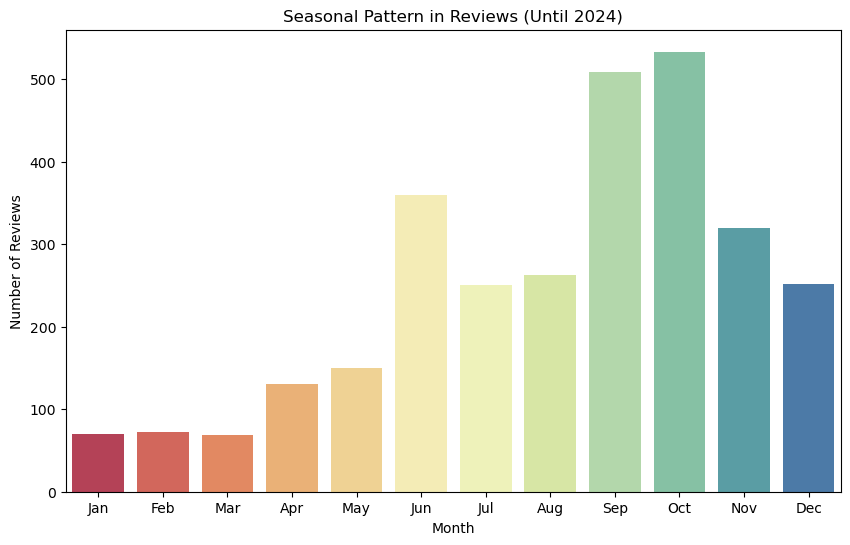

In [20]:
# Reviews over time (seasonality)
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')
reviews_time = df_clean.dropna(subset=['last_review'])
reviews_until_2024 = reviews_time[reviews_time['last_review'] < '2025-01-01']

# Monthly review counts
monthly_counts = (
    reviews_until_2024.groupby(reviews_until_2024['last_review'].dt.month)
    .size()
    .reset_index(name='review_count')
)

plt.figure(figsize=(10,6))
sns.barplot(data=monthly_counts, x='last_review', y='review_count', palette="Spectral")
plt.xticks(
    ticks=range(0,12),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Seasonal Pattern in Reviews (Until 2024)")
plt.show()


/tmp/ipykernel_5373/3609742865.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


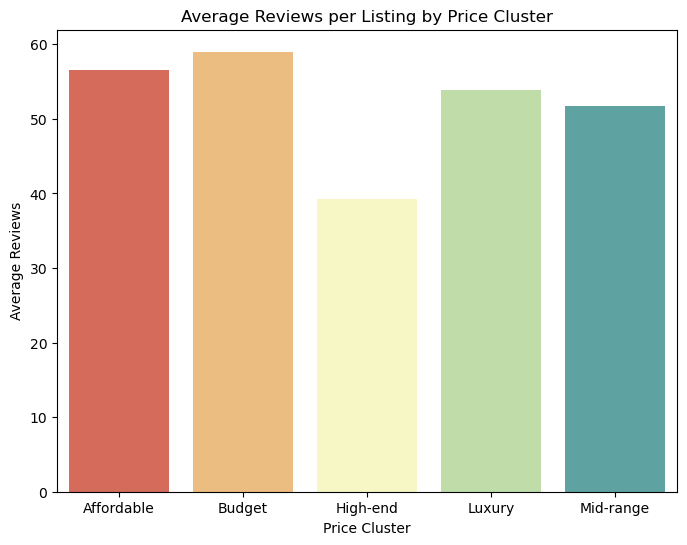

In [22]:
#  Reviews per price cluster
reviews_by_cluster = (
    df_clean.groupby('price_kmeans_named')['number_of_reviews']
    .agg(['mean','median','count'])
    .reset_index()
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=reviews_by_cluster,
    x='price_kmeans_named',
    y='mean',
    palette="Spectral"
)
plt.title("Average Reviews per Listing by Price Cluster")
plt.xlabel("Price Cluster")
plt.ylabel("Average Reviews")
plt.show()


/tmp/ipykernel_5373/605096458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


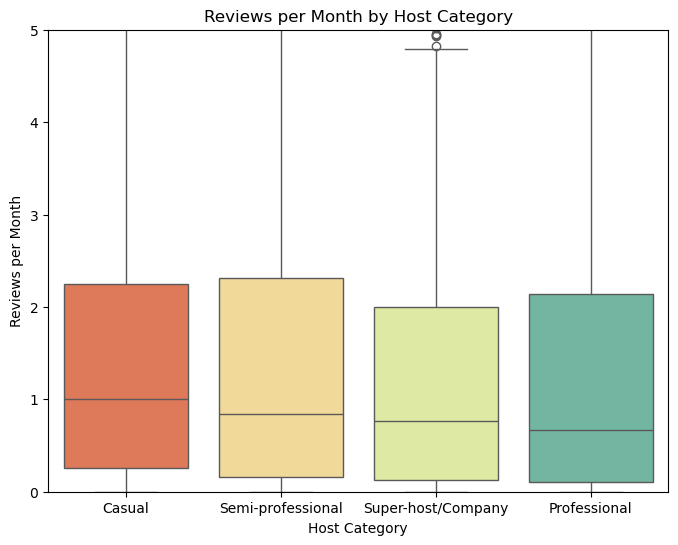

In [23]:
#  Reviews vs host category
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_clean,
    x='host_category',
    y='reviews_per_month',
    palette="Spectral"
)
plt.ylim(0, 5)
plt.title("Reviews per Month by Host Category")
plt.xlabel("Host Category")
plt.ylabel("Reviews per Month")
plt.show()


### Review Insights

- Most listings have relatively few reviews, with a long tail of highly reviewed properties.  
- Review activity is seasonal: it peaks in June, drops in July-August, and rises again in September-October.  
- The relationship between price and review activity is weak, suggesting that reviews are not a strong predictor of nightly price.  

**Takeaway**: Review patterns reflect guest demand and seasonality more than pricing strategy. Most Athens listings receive limited feedback, and review-related variables have only a weak relationship with price.


## 8.6 Minimum Nights & Availability

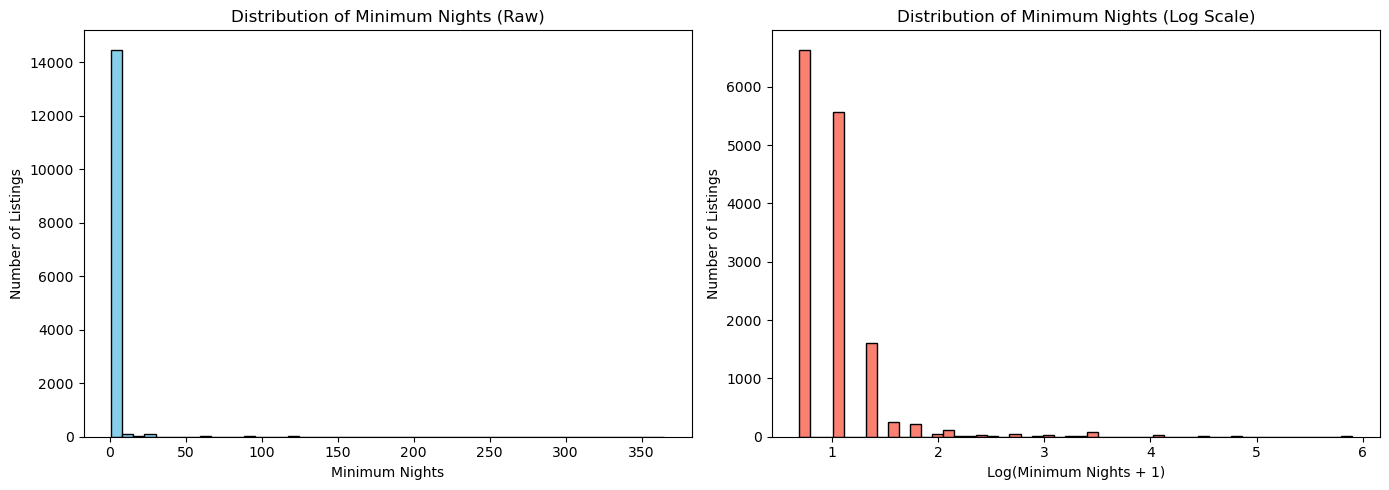

In [24]:
# Columns: minimum_nights, log_minimum_nights, availability_365
# ---------------------------------------------

#  Distribution of Minimum Nights
df_clean['log_minimum_nights'] = np.log1p(df_clean['minimum_nights'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Raw scale
axes[0].hist(df_clean['minimum_nights'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title("Distribution of Minimum Nights (Raw)")
axes[0].set_xlabel("Minimum Nights")
axes[0].set_ylabel("Number of Listings")

# Log scale
axes[1].hist(df_clean['log_minimum_nights'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title("Distribution of Minimum Nights (Log Scale)")
axes[1].set_xlabel("Log(Minimum Nights + 1)")
axes[1].set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

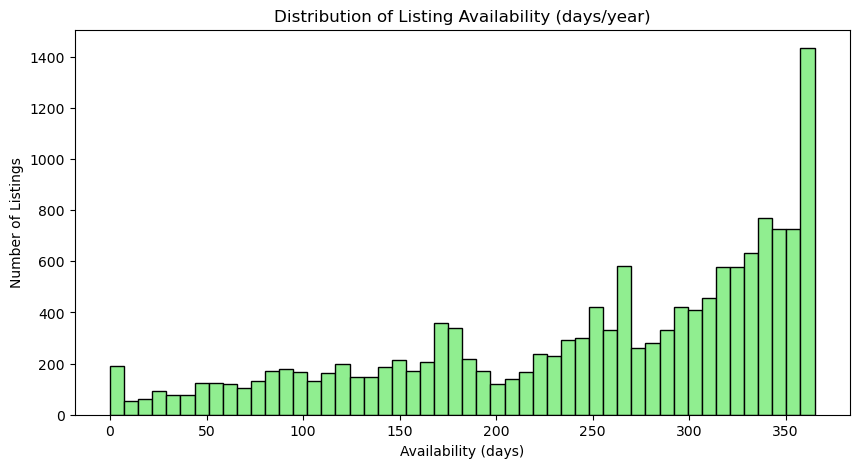

In [25]:
# Distribution of Availability
plt.figure(figsize=(10,5))
plt.hist(df_clean['availability_365'], bins=50, color='lightgreen', edgecolor='black')
plt.title("Distribution of Listing Availability (days/year)")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Listings")
plt.show()


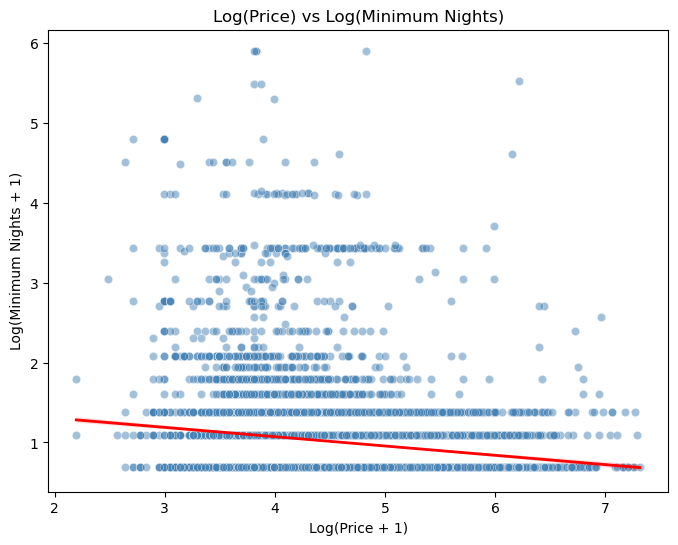

Correlation (log-log): -0.17


In [26]:
#  Relationship between Minimum Nights and Price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clean,
    x='log_price',
    y='log_minimum_nights',
    alpha=0.5,
    color='steelblue'
)
sns.regplot(
    data=df_clean,
    x='log_price',
    y='log_minimum_nights',
    scatter=False,
    color='red',
    line_kws={'linewidth':2}
)
plt.title("Log(Price) vs Log(Minimum Nights)")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Log(Minimum Nights + 1)")
plt.show()

corr = df_clean['log_price'].corr(df_clean['log_minimum_nights'])
print(f"Correlation (log-log): {corr:.2f}")

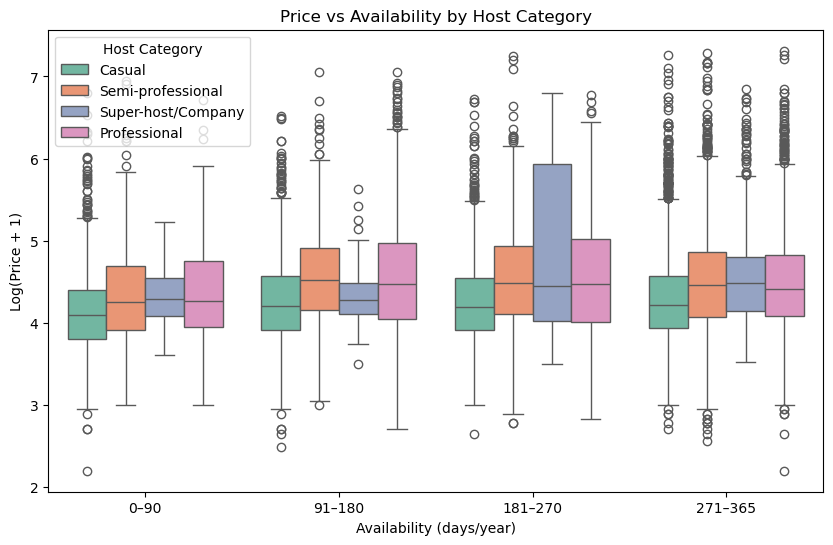

In [27]:
#  Price vs Availability Bins by Host Category
bins = [0, 90, 180, 270, 365]
labels = ['0–90', '91–180', '181–270', '271–365']

df_clean['availability_bin'] = pd.cut(
    df_clean['availability_365'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_clean,
    x='availability_bin',
    y='log_price',
    hue='host_category',
    palette='Set2'
)
plt.title("Price vs Availability by Host Category")
plt.xlabel("Availability (days/year)")
plt.ylabel("Log(Price + 1)")
plt.legend(title='Host Category')
plt.show()

/tmp/ipykernel_5373/2688437162.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


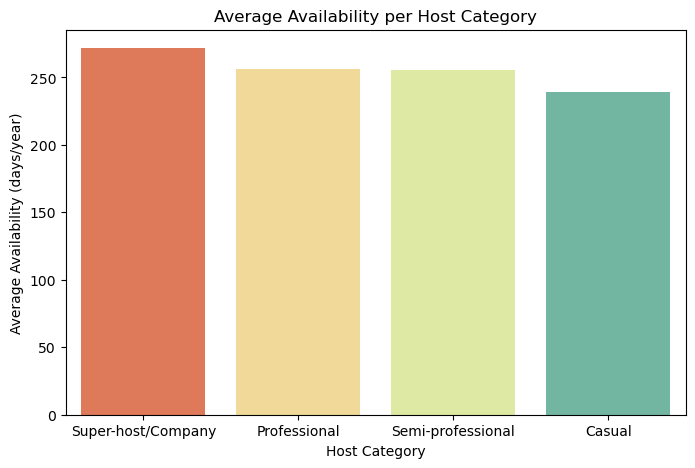

In [28]:
# Average Availability per Host Category
avg_availability = (
    df_clean.groupby('host_category')['availability_365']
    .mean()
    .reset_index()
    .sort_values('availability_365', ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=avg_availability,
    x='host_category',
    y='availability_365',
    palette="Spectral"
)
plt.title("Average Availability per Host Category")
plt.xlabel("Host Category")
plt.ylabel("Average Availability (days/year)")
plt.show()

### Minimum Nights and Availability Insights

- Most listings require short stays, usually between one and seven nights.  
- Extreme minimum-night values are rare and have little relationship with price.  
- Availability is widely dispersed across listings, but it varies more with host strategy than with pricing.

**Takeaway**: Minimum stay rules and availability reflect how hosts manage their listings rather than strong market-wide pricing effects.


## 8.7 License

In [29]:
# Licensing Coverage Summary
total_listings = len(df_clean)
unlicensed_count = (df_clean['license'] == "Unlicensed").sum()
unlicensed_percentage = unlicensed_count / total_listings * 100

print(f"Licensed listings: {total_listings - unlicensed_count} ({100 - unlicensed_percentage:.2f}%)")
print(f"Unlicensed listings: {unlicensed_count} ({unlicensed_percentage:.2f}%)")

Licensed listings: 14584 (98.83%)
Unlicensed listings: 172 (1.17%)


/tmp/ipykernel_5373/4075235372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


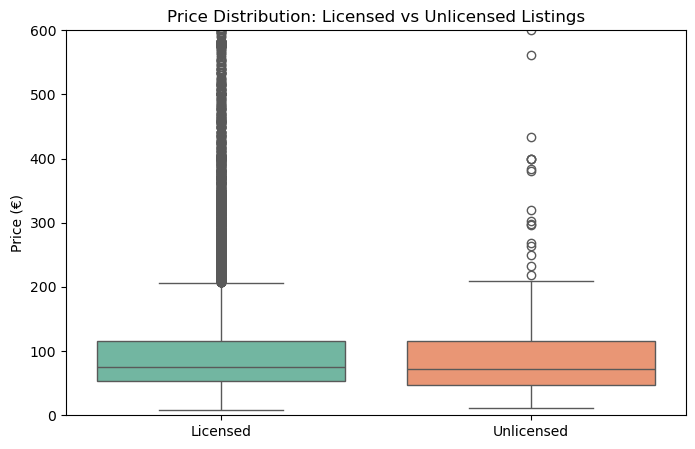

In [30]:
# Price Distribution by Licensing Status
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x=df_clean['license'] == "Unlicensed",
    y='price',
    palette='Set2'
)
plt.ylim(0, 600)
plt.xticks([0, 1], ['Licensed', 'Unlicensed'])
plt.title("Price Distribution: Licensed vs Unlicensed Listings")
plt.ylabel("Price (€)")
plt.xlabel("")
plt.show()

/tmp/ipykernel_5373/4033741557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


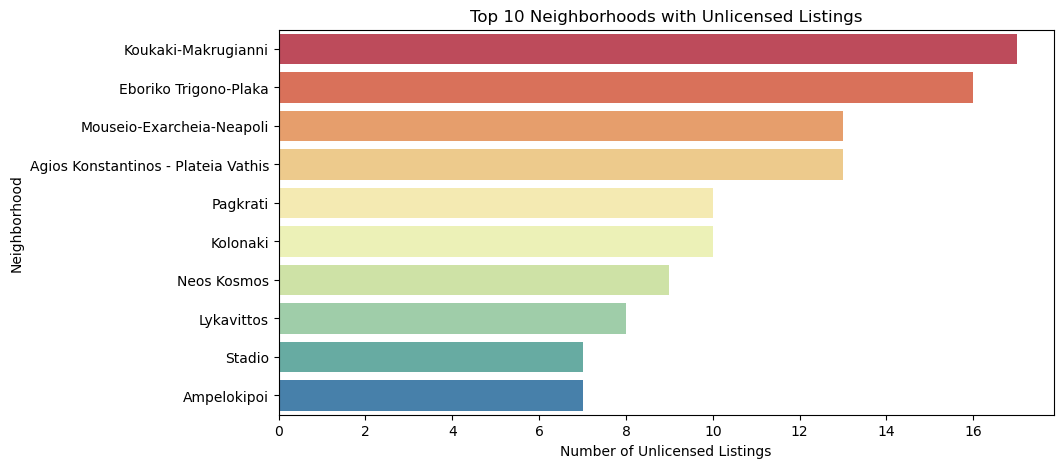

In [31]:
# Geographic Concentration of Unlicensed Listings
unlicensed_neigh = (
    df_clean[df_clean['license'] == "Unlicensed"]
    ['neighbourhood']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=unlicensed_neigh.values,
    y=unlicensed_neigh.index,
    palette="Spectral"
)
plt.title("Top 10 Neighborhoods with Unlicensed Listings")
plt.xlabel("Number of Unlicensed Listings")
plt.ylabel("Neighborhood")
plt.show()

### License Insights

- More than 98% of listings include a license number.  
- Unlicensed listings make up a very small share of the dataset and show no meaningful difference in price or location patterns.  

**Takeaway**: Licensing status is nearly universal in this dataset and does not add much explanatory power for modeling.


## 8.8 Listing Titles and Keywords

Listing titles provide a lightweight text-based view of how properties are positioned in the market.  
This section looks at the most common keywords overall and by price cluster to see whether premium and budget listings describe themselves differently.


/tmp/ipykernel_5373/3649677244.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


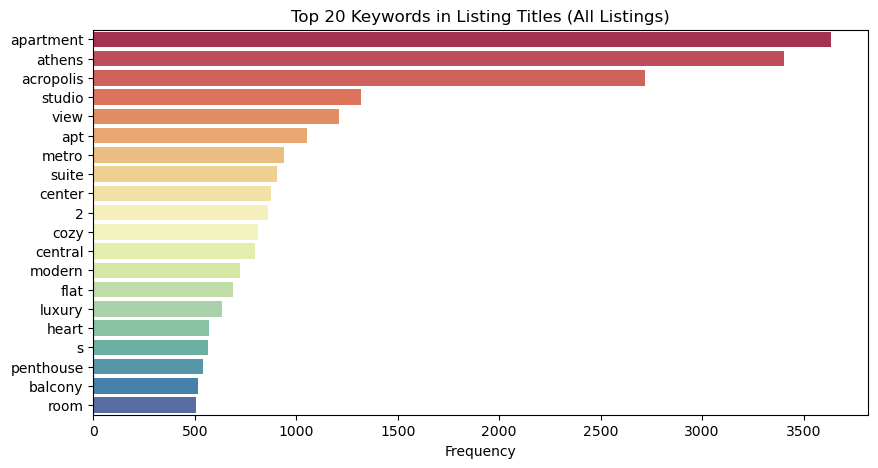

In [32]:
import re
from collections import Counter
# Basic English stopwords (custom minimal list)
stopwords = set([
    'the', 'a', 'an', 'and', 'of', 'in', 'on', 'at', 'for', 'to',
    'with', 'is', 'by', 'from', 'near', 'as', 'this', 'that', 'its', 'it'
])

# Helper function
def extract_words(text):
    """Extract lowercase words from text, filtering out stopwords."""
    words = re.findall(r'\b\w+\b', str(text).lower())
    return [w for w in words if w not in stopwords]

# Overall Top Keywords 
all_names = df_clean['name'].dropna()
all_words = [w for name in all_names for w in extract_words(name)]
word_counts = Counter(all_words)

top_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_words,
    y='Word',
    x='Frequency',
    palette='Spectral'
)
plt.title("Top 20 Keywords in Listing Titles (All Listings)")
plt.xlabel("Frequency")
plt.ylabel("")
plt.show()

In [33]:
# Top Keywords by Price Cluster 

clusters = df_clean['price_kmeans_named'].unique()
top_n = 8

cluster_keywords = {}

for cluster in clusters:
    cluster_names = df_clean[df_clean['price_kmeans_named'] == cluster]['name']
    cluster_words = [w for name in cluster_names for w in extract_words(name)]
    top_words = Counter(cluster_words).most_common(top_n)
    cluster_keywords[cluster] = top_words

# Display cluster-specific results
for cluster, words in cluster_keywords.items():
    print(f"\nTop {top_n} keywords for '{cluster}' listings:")
    for word, count in words:
        print(f"  - {word}: {count}")


Top 8 keywords for 'Budget' listings:
  - athens: 635
  - apartment: 609
  - studio: 402
  - cozy: 282
  - metro: 271
  - room: 233
  - acropolis: 216
  - central: 195

Top 8 keywords for 'Affordable' listings:
  - apartment: 1355
  - athens: 1239
  - acropolis: 695
  - studio: 545
  - metro: 407
  - apt: 349
  - cozy: 346
  - center: 342

Top 8 keywords for 'Mid-range' listings:
  - apartment: 1066
  - athens: 957
  - acropolis: 938
  - view: 403
  - apt: 369
  - studio: 298
  - 2: 281
  - suite: 254

Top 8 keywords for 'Luxury' listings:
  - acropolis: 643
  - apartment: 495
  - athens: 445
  - view: 311
  - suite: 259
  - apt: 184
  - luxury: 166
  - 2: 133

Top 8 keywords for 'High-end' listings:
  - acropolis: 226
  - suite: 172
  - athens: 129
  - view: 115
  - apartment: 112
  - suites: 103
  - zeus: 93
  - penthouse: 65


### Keyword Insights

- Common terms such as "studio", "apartment", "central", and "Athens" dominate listing titles, indicating a market centered on compact urban stays.  
- High-end clusters use words such as "luxury", "suite", "view", and "Acropolis" more often, while lower-priced clusters rely more on convenience-oriented language such as "cozy", "room", and "near metro".

**Takeaway**: Listing titles reinforce the broader EDA findings: the Athens Airbnb market is city-center focused, apartment-heavy, and clearly segmented by price.


## 9) Feature Engineering

Before modeling, a small set of features was engineered to improve interpretability and reduce skewness.  
The focus here is not to create many derived variables, but to retain a compact set that reflects the main EDA findings.


In [34]:
# Define target
TARGET = "log_price"  # log-transformed price
y = df_clean[TARGET]

# Numeric features
numeric_cols = [
    "number_of_reviews_ltm",
    "log_minimum_nights",
    "availability_365"
]

# Categorical features
categorical_cols = [
    "room_type",
    "host_category"
]

# Add location clusters (5 clusters found earlier)
coords = df_clean[["latitude", "longitude"]]
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean["location_cluster"] = kmeans.fit_predict(coords)
categorical_cols.append("location_cluster")

# Build feature matrix
X = df_clean[numeric_cols + categorical_cols].copy()

# One-hot encode categoricals
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Feature matrix built. Shape:", X.shape)
print("Target vector built. Shape:", y.shape)


Feature matrix built. Shape: (14756, 12)
Target vector built. Shape: (14756,)


### Feature Engineering Overview

The final modeling dataset uses:
- **Log transformations** for skewed variables such as `log_price` and `log_minimum_nights`
- **Categorical grouping** for room type and host type
- **Location clusters** based on latitude and longitude

These features provide a compact, interpretable baseline for regression modeling.


## 10) Train/Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split done.")
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Split done.
Train shape: (11804, 12)  Test shape: (2952, 12)


## 11) Baseline Model: Linear Regression

In [41]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression fitted.")
print(f"RMSE: {rmse:.4f}")
print(f"R²:  {r2:.4f}")

Linear Regression fitted.
RMSE: 0.6053
R²:  0.1651


### Linear Regression

A simple **Linear Regression** is used as the baseline model to predict `log_price`.
This serves as a performance benchmark for potential future models (e.g., regularized regressors, tree-based methods).

Evaluation metrics:
- **RMSE (Root Mean Squared Error)** — measures average prediction error in log-price units.  
- **R² (R-squared)** — explains the proportion of price variability captured by the model.


## 12) Evaluation and Diagnostics

This section evaluates the baseline model using performance metrics, coefficient estimates, multicollinearity checks, and residual diagnostics.


In [42]:
# --- Model Performance ---
# Using metrics from model evaluation (computed earlier during training)
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "R²"],
    "Value": [rmse, r2]
})
print("Model Performance Metrics")
display(metrics_df)

Model Performance Metrics


,Metric,Value
0,RMSE,0.605297
1,R²,0.165133


In [43]:
# --- Multicollinearity Check (VIF) ---
# VIF helps identify redundant or highly correlated predictors that may distort regression estimates.
X_vif = X.astype(float)

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF)")
display(vif_data)

Variance Inflation Factors (VIF)


,feature,VIF
2,availability_365,5.038604
1,log_minimum_nights,4.180172
9,location_cluster_2,2.088243
5,host_category_Professional,1.660231
6,host_category_Semi-professional,1.646951
11,location_cluster_4,1.581522
8,location_cluster_1,1.485729
0,number_of_reviews_ltm,1.443659
10,location_cluster_3,1.427503
7,host_category_Super-host/Company,1.228294


In [44]:
# --- OLS Model Summary (Statsmodels) ---
# Statsmodels provides a detailed view of each coefficient, standard error, and p-value.

X_const = sm.add_constant(X_vif)
ols_model = sm.OLS(y, X_const).fit()

print("OLS Regression Summary")
display(ols_model.summary())


OLS Regression Summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     249.3
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:05   Log-Likelihood:                -13157.
No. Observations:               14756   AIC:                         2.634e+04
Df Residuals:                   14743   BIC:                         2.644e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                4.6858      0.022    215.618      0.000       4.643       4.728
number_of_reviews_ltm               -0.0036      0.000    -13.848      0.000      -0.004      -0.003
log_minimum_nights                  -0.1446      0.011    -13.038      0.000      -0.166      -0.123
availability_365                  6.052e-05   4.93e-05      1.228      0.220   -3.61e-05       0.000
room_type_Private room              -0.3757      0.020    -18.376      0.000      -0.416      -0.336
room_type_Shared room               -1.0381      0.108     -9.595      0.000      -1.250      -0.826
host_category_Professional           0.1672      0.013     13.302      0.000       0.143       0.192
host_category_Semi-professional      0.1824      0.013     14.384      0.000       0.158       0.207
host_category_Super-host/Company     0.1976      0.020     10.072      0.000       0.159       0.236
location_cluster_1                  -0.5747      0.017    -34.391      0.000      -0.607      -0.542
location_cluster_2                  -0.0422      0.013     -3.201      0.001      -0.068      -0.016
location_cluster_3                  -0.1758      0.017    -10.499      0.000      -0.209      -0.143
location_cluster_4                  -0.2991      0.016    -19.050      0.000      -0.330      -0.268
==============================================================================
Omnibus:                     2195.619   Durbin-Watson:                   1.671
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3839.377
Skew:                           0.975   Prob(JB):                         0.00
Kurtosis:                       4.563   Cond. No.                     6.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
# --- Coefficients and p-values ---
# Easier comparison of which variables are most influential and statistically significant.

coef_table = (
    pd.DataFrame({
        "feature": X_const.columns,
        "coefficient": ols_model.params,
        "p_value": ols_model.pvalues
    })
    .sort_values(by="coefficient", key=abs, ascending=False)
)

print("Top coefficients with p-values:")
display(coef_table.head(10))

Top coefficients with p-values:


,feature,coefficient,p_value
const,const,4.685831,0.000000e+00
room_type_Shared room,room_type_Shared room,-1.038086,9.692938e-22
location_cluster_1,location_cluster_1,-0.574691,2.130554e-249
room_type_Private room,room_type_Private room,-0.375732,1.384029e-74
location_cluster_4,location_cluster_4,-0.299074,6.004307e-80
host_category_Super-host/Company,host_category_Super-host/Company,0.197561,8.746797e-24
host_category_Semi-professional,host_category_Semi-professional,0.182424,1.343630e-46
location_cluster_3,location_cluster_3,-0.175758,1.073645e-25
host_category_Professional,host_category_Professional,0.167189,3.820199e-40
log_minimum_nights,log_minimum_nights,-0.144587,1.219613e-38


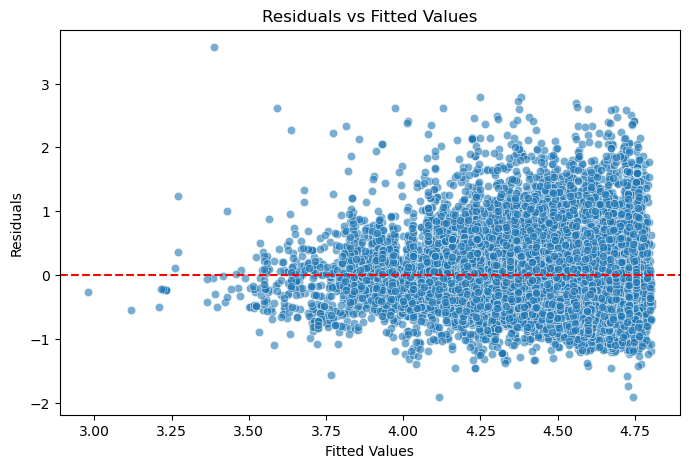

In [46]:
# --- Residual Diagnostics ---
# Residuals should be randomly scattered around zero with no clear pattern.

residuals = ols_model.resid
fitted = ols_model.fittedvalues

plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

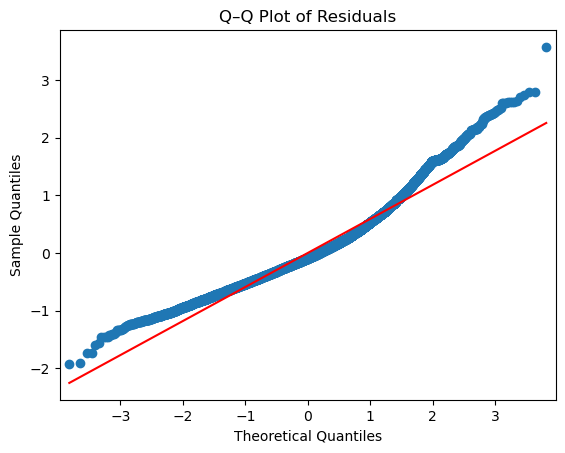

In [47]:
# --- Residual Normality Check ---
# A Q-Q plot helps evaluate whether residuals follow a normal distribution.
sm.qqplot(residuals, line='s')
plt.title("Q–Q Plot of Residuals")
plt.show()

### Evaluation Summary

- The baseline model explains a moderate share of variation in `log_price`, which is reasonable given the limited number of features.
- The strongest signals come from room type and location, while operational variables such as availability contribute less.
- VIF values remain within an acceptable range, suggesting that multicollinearity is present but not severe.
- Residual plots indicate that the model is usable as a baseline, although non-linear patterns likely remain.

A more flexible model could improve performance, but the current regression provides a clear and interpretable starting point.


## 13) Final Interpretation and Next Steps

This final section summarizes the main modeling results and suggests practical directions for improvement.


### Final Interpretation

The baseline regression suggests that Airbnb prices in Athens are driven mainly by **location** and **room type**. Central areas close to the Acropolis and other major attractions consistently appear in higher price clusters, while private rooms and shared rooms remain substantially cheaper than entire homes.

Review activity, availability, and host size show weaker relationships with price. These variables may still capture useful behavioral patterns, but they do not explain price variation nearly as strongly as geography and property type.

As a first model, linear regression serves mainly as an interpretable benchmark. A next step would be to compare it with regularized models or tree-based methods, especially if the goal shifts from explanation to prediction.
